<a href="https://colab.research.google.com/github/vivianlinnn/DS41_IDXExchange/blob/main/src/08_LightGBM_EvaluationRange_Anjali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start: Anjali Manju Gowda

## 1. Import Libraries

We import the necessary libraries for data handling and numerical computation:

- `pandas` → For loading CSV files, manipulating data, and aggregating results.
- `numpy` → For performing numerical operations like MAPE and median errors.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Predicted Data

We load the LightGBM predictions CSV (`lightgbm_test.csv`) which contains:

- `ClosePrice` → Actual property prices
- `Predicted_Price` → Predicted property prices from the LightGBM model
- `Predicted_LogPrice` → Log-transformed predicted prices

In [19]:
df = pd.read_csv('/content/lightgbm_test.csv')

## 3. Define Price Ranges

We divide properties into log-price bands using `pd.cut`:

- `bins = [12, 13, 14, 15, 16]` → Defines the range edges
- `labels = ['[12-13)','[13-14)','[14-15)', '[15-16)']` → Labels for each range
- Assign each property a `Price_Range` label for further analysis

In [20]:
bins = [12, 13, 14, 15, 16]
labels = ['[12-13)','[13-14)','[14-15)', '[15-16)']

df['Price_Range'] = pd.cut(df['Predicted_LogPrice'], bins=bins, labels=labels)

In [21]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 4. Define MAPE Function

Mean Absolute Percentage Error (MAPE) measures average prediction accuracy as a percentage:


## 5. Compute Range-wise Metrics

We group the data by `Price_Range` and calculate:

- `Count` → Number of properties in each range
- `Avg_Actual_Price` → Mean actual closing price
- `Avg_Predicted_Price` → Mean predicted price
- `MAPE (%)` → Mean absolute percentage error for the range
- `MdAPE (%)` → Median absolute percentage error (robust to outliers)

In [22]:
range_analysis = df.groupby('Price_Range', observed=False, group_keys=False).apply(
    lambda x: pd.Series({
        'Count': len(x),
        'Avg_Actual_Price': x['ClosePrice'].mean(),
        'Avg_Predicted_Price': x['Predicted_Price'].mean(),
        'MAPE (%)': mape(x['ClosePrice'], x['Predicted_Price']),
        'MdAPE (%)': np.median(np.abs((x['ClosePrice'] - x['Predicted_Price']) / x['ClosePrice'])) * 100
    }),
    include_groups=False
).reset_index()

## 6. Display & Save Results

- `print(range_analysis)` → Shows a summary table of predictions vs actuals by price range.
- `to_csv()` → Saves the analysis as `lightgbm_range_analysis.csv` for reporting or visualization.

In [23]:
print(range_analysis)
range_analysis.to_csv('/content/lightgbm_range_analysis.csv', index=False)

  Price_Range   Count  Avg_Actual_Price  Avg_Predicted_Price   MAPE (%)  \
0     [12-13)   929.0      3.679049e+05         3.679166e+05  14.185045   
1     [13-14)  6359.0      7.950910e+05         7.837589e+05  13.397299   
2     [14-15)  2713.0      1.809846e+06         1.773584e+06  17.746380   
3     [15-16)   313.0      4.598803e+06         4.384979e+06  20.801998   

   MdAPE (%)  
0  10.046122  
1   9.399190  
2  13.124690  
3  16.915617  


## LightGBM Model Performance & Range-wise Analysis

### Overall Model Performance

- **Test R²**: 0.8903  
- **Test MAPE**: 14.84%  
- **Test MdAPE**: 10.50%  

📊 Range-wise Performance Analysis (LightGBM)

The model performance was evaluated across different log-price ranges to understand prediction accuracy at various price levels.

🔍 Key Insights

• Best Performing Range → [13–14)  
  - Lowest error (MAPE ≈ 13.4%, MdAPE ≈ 9.4%)  
  - Largest number of samples  
  - Model learns patterns effectively → most reliable predictions  

• Stable Performance → [12–13)  
  - Slightly higher error (MAPE ≈ 14.2%)  
  - Predictions closely match actual values  
  - Good consistency in lower price range  

• Performance Drop → [14–15)  
  - Error increases (MAPE ≈ 17.7%)  
  - Model begins to underpredict  
  - Indicates increased complexity in mid-high priced homes  

• Worst Performance → [15–16)  
  - Highest error (MAPE ≈ 20.8%)  
  - Very few samples → weak learning  
  - Model struggles with luxury/high-value properties  


## 7. Visualize Range-wise Predictions

We create a bar plot to compare:

- Average actual price vs predicted price in each log-price range.
- Helps to visually identify where the model is performing well or underestimating/overestimating.

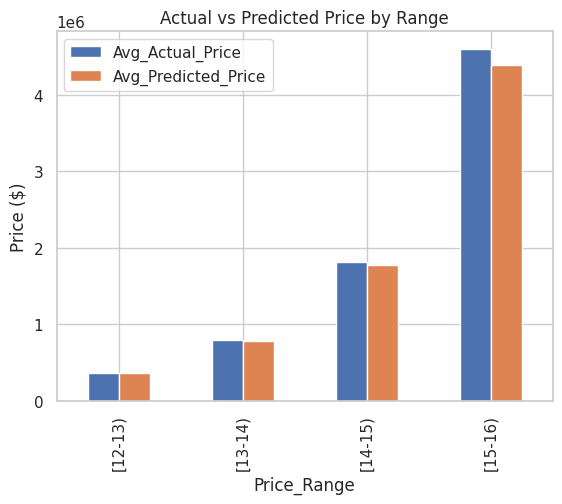

In [24]:
range_analysis.set_index('Price_Range')[['Avg_Actual_Price','Avg_Predicted_Price']].plot(kind='bar')
plt.title('Actual vs Predicted Price by Range')
plt.ylabel('Price ($)')
plt.show()

📈 Final Conclusion

The LightGBM model performs best for mid-range properties and maintains stable performance for lower-priced homes.  
Performance declines in higher price segments due to:
- Limited data availability  
- Greater variability in luxury property features  

Improving predictions in high-price ranges may require:
- More data  
- Additional feature engineering  
- Specialized modeling approaches

# END: Anjali Manju Gowda